<h1>Resampling</h1>

In [1]:
%matplotlib inline

import random
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power
import matplotlib.pylab as plt



qsar = pd.read_csv("train.csv")




Observed mean difference: 43.85826213640004


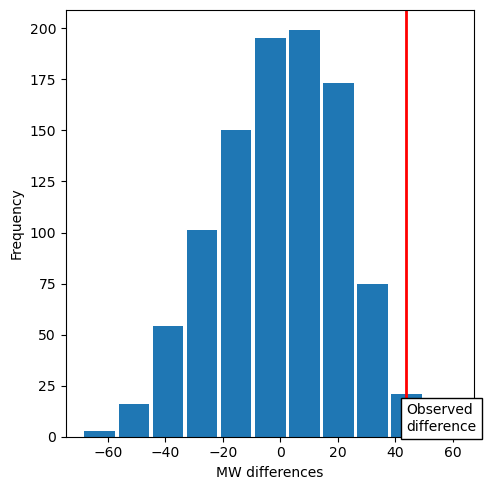

Permutation p-value: 0.017


In [11]:
# LogP 기준으로 두 그룹 쪼개기 -> 분자량 측면에서 평균 다른지 보기기
median_logp = qsar["LogP"].median()
qsar["group"] = np.where(qsar["LogP"] >= median_logp, "High", "Low") # logp가 낮은 그륩, 높은 그륩


qsar = qsar.sample(n=100, random_state=42).reset_index(drop=True)
median_logp = qsar["LogP"].median()
qsar["group"] = np.where(qsar["LogP"] >= median_logp, "High", "Low")

# -----------------------------
# 3️⃣ MW (분자량) 비교
# -----------------------------
col = "MW"
mean_low = qsar.loc[qsar["group"] == "Low", col].mean()
mean_high = qsar.loc[qsar["group"] == "High", col].mean()
print("Observed mean difference:", mean_high - mean_low)

# -----------------------------
# 4️⃣ Permutation Test
# -----------------------------
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

nA = qsar[qsar["group"] == "High"].shape[0]
nB = qsar[qsar["group"] == "Low"].shape[0]

random.seed(1)
perm_diffs = [perm_fun(qsar[col], nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=mean_high - mean_low, color="red", lw=2)
ax.text(mean_high - mean_low, 3, "Observed\ndifference", bbox={"facecolor": "white"})
ax.set_xlabel(f"{col} differences")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

perm_diffs = np.array(perm_diffs)
print("Permutation p-value:", np.mean(perm_diffs > mean_high - mean_low))




In [12]:
qsar["MW"].corr(qsar["LogP"])

np.float64(0.17034525617175197)

Observed mean difference: 43.8583


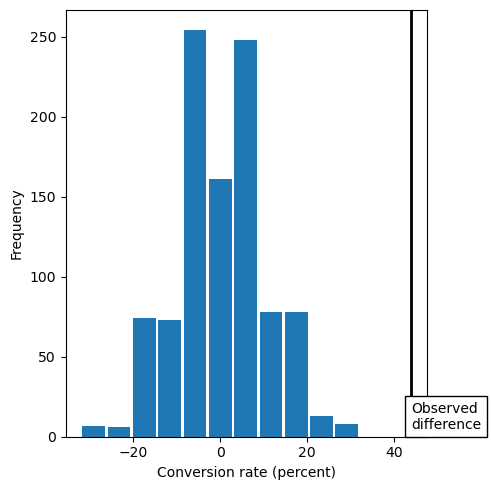

Permutation p-value: 0.0000


In [15]:
median_logp = qsar["LogP"].median()
conversion = pd.Series(np.where(qsar["LogP"] >= median_logp, 1, 0))

# -----------------------------
# 3️⃣ 실제 관측된 비율 차이 계산
# -----------------------------
# 수정 코드 ✅
obs_diff = qsar.loc[conversion == 1, "MW"].mean() - qsar.loc[conversion == 0, "MW"].mean()
print(f"Observed mean difference: {obs_diff:.4f}")


# -----------------------------
# 4️⃣ Permutation Test
# -----------------------------
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = random.sample(range(n), nB)
    idx_A = list(set(range(n)) - set(idx_B))
    return x.iloc[idx_B].mean() - x.iloc[idx_A].mean()

random.seed(1)
perm_diffs = [
    100 * perm_fun(conversion, nA=conversion.sum(), nB=len(conversion) - conversion.sum())
    for _ in range(1000)
]

# -----------------------------
# 5️⃣ 시각화
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_diff, color="black", lw=2)
ax.text(obs_diff, 5, "Observed\ndifference", bbox={"facecolor": "white"})
ax.set_xlabel("Conversion rate (percent)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------------
# 6️⃣ p-value 계산
# -----------------------------
p_val = np.mean([diff > obs_diff for diff in perm_diffs])
print(f"Permutation p-value: {p_val:.4f}")

In [16]:
# t-test 
res = stats.ttest_ind(
    qsar.loc[qsar["group"]=="High", col],
    qsar.loc[qsar["group"]=="Low", col],
    equal_var=False
)
print(f'p-value (single sided): {res.pvalue/2}')




p-value (single sided): 0.021591940032339246


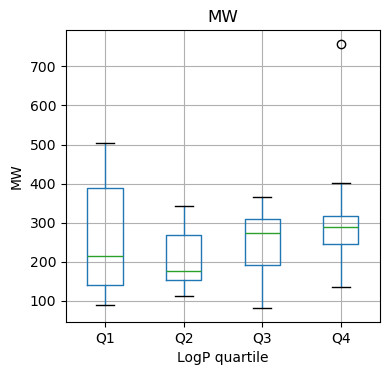

/tmp/ipykernel_1405/1918931281.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observed_means = qsar.groupby("LogP_bin")[col].mean()
/tmp/ipykernel_1405/1918931281.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby("LogP_bin")[col].mean().var()


Observed means: [261.10427416 204.45800907 258.64643157 294.63237594]
Observed variance: 1391.813642702513
Pr(Prob) 0.0215


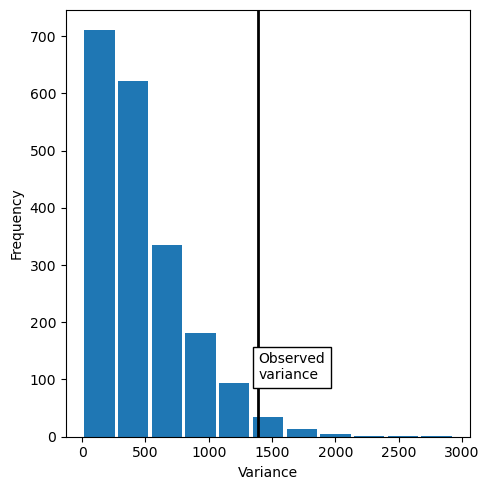


ANOVA Table:
               df        sum_sq       mean_sq         F    PR(>F)
C(LogP_bin)   3.0  1.043860e+05  34795.341068  3.133688  0.029093
Residual     96.0  1.065949e+06  11103.639898       NaN       NaN

F-Statistic: 3.1337
p-value: 0.0291


In [17]:
# 사용할 컬럼 지정 (모두 numeric으로 제한)
numeric_cols = qsar.select_dtypes(include=[np.number]).columns.tolist()

# MW만 대상으로 예시 (책의 Time 변수 역할)
col = "MW"

# ===== LogP를 4개 구간으로 나누기 (책의 Page 1~4 대응) =====
qsar["LogP_bin"] = pd.qcut(qsar["LogP"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

# ===== 박스플롯 =====
ax = qsar.boxplot(by="LogP_bin", column=col, figsize=(4, 4))
ax.set_xlabel("LogP quartile")
ax.set_ylabel(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

# ===== 그룹별 평균과 분산 계산 (object 컬럼 제외) =====
observed_means = qsar.groupby("LogP_bin")[col].mean()
observed_variance = observed_means.var()

print("Observed means:", observed_means.values)
print("Observed variance:", observed_variance)

# ===== Permutation test for ANOVA =====
def perm_test(df, col):
    df = df.copy()
    df[col] = np.random.permutation(df[col].values)
    return df.groupby("LogP_bin")[col].mean().var()

random.seed(1)
perm_variance = [perm_test(qsar, col) for _ in range(2000)]
print("Pr(Prob)", np.mean([var > observed_variance for var in perm_variance]))

# ===== 분포 시각화 =====
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x=observed_variance, color="black", lw=2)
ax.text(observed_variance, 100, "Observed\nvariance", bbox={"facecolor": "white"})
ax.set_xlabel("Variance")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# ===== F-Statistic (ANOVA table) =====
model = smf.ols(f"{col} ~ C(LogP_bin)", data=qsar).fit()
aov_table = sm.stats.anova_lm(model)
print("\nANOVA Table:")
print(aov_table)

# ===== F-test directly =====
res = stats.f_oneway(
    *[qsar.loc[qsar["LogP_bin"] == g, col] for g in qsar["LogP_bin"].unique()]
)
print(f"\nF-Statistic: {res.statistic:.4f}")
print(f"p-value: {res.pvalue:.4f}")

In [9]:
# MW를 median 기준으로 고/저 구분
qsar["MW_bin"] = (qsar["MW"] > qsar["MW"].median()).astype(int)
cont_table = pd.crosstab(qsar["MW_bin"], qsar["LogP_bin"])
print(cont_table)

chi2, p_value, df, _ = stats.chi2_contingency(cont_table)
print(f"Chi-square: {chi2:.4f}, p-value: {p_value:.4f}")


LogP_bin    Q1    Q2    Q3    Q4
MW_bin                          
0         1610  1618  1292   636
1          978   953  1284  1926
Chi-square: 975.8787, p-value: 0.0000


In [10]:
effect_size = sm.stats.proportion_effectsize(0.55, 0.45)  # 임의 예시
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, alternative='larger')
print(f"Required sample size: {result:.3f}")


Required sample size: 308.774


Original: 100 rows, After cleaning: 99 rows


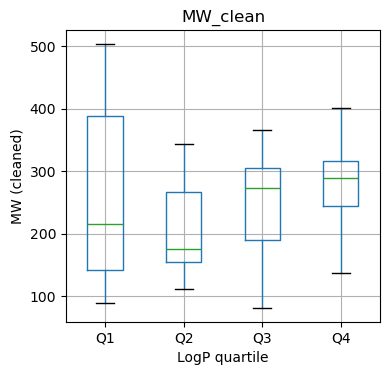

/tmp/ipykernel_1405/3321541089.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observed_means = qsar_clean.groupby("LogP_bin")["MW_clean"].mean()
/tmp/ipykernel_1405/3321541089.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby("LogP_bin")[col].mean().var()


Observed means: [261.10427416 204.45800907 255.33623296 277.81524925]
Observed variance: 999.7092386268133
Permutation p-value: 0.04000


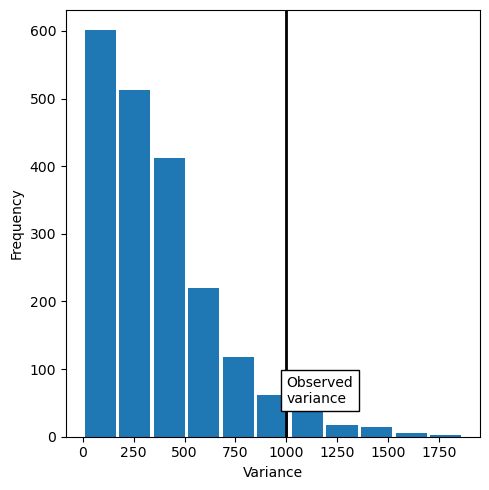


ANOVA Table:
               df         sum_sq       mean_sq       F    PR(>F)
C(LogP_bin)   3.0   74945.858952  24981.952984  2.8287  0.042616
Residual     95.0  839002.117984   8831.601242     NaN       NaN

F-Statistic: 2.8287
p-value: 0.0426


In [20]:
# MW > 850 제거한 새로운 컬럼 생성
qsar["MW_clean"] = qsar["MW"].where(qsar["MW"] <= 700, np.nan)

# outlier 제거된 행만 사용
qsar_clean = qsar.dropna(subset=["MW_clean"]).copy()
print(f"Original: {len(qsar)} rows, After cleaning: {len(qsar_clean)} rows")

# ===============================
# 2. LogP를 4개 구간으로 나누기 (책의 Page 1~4 대응)
# ===============================
qsar_clean["LogP_bin"] = pd.qcut(qsar_clean["LogP"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

# ===============================
# 3. 박스플롯
# ===============================
ax = qsar_clean.boxplot(by="LogP_bin", column="MW_clean", figsize=(4, 4))
ax.set_xlabel("LogP quartile")
ax.set_ylabel("MW (cleaned)")
plt.suptitle("")
plt.tight_layout()
plt.show()

# ===============================
# 4. 그룹별 평균/분산
# ===============================
observed_means = qsar_clean.groupby("LogP_bin")["MW_clean"].mean()
observed_variance = observed_means.var()

print("Observed means:", observed_means.values)
print("Observed variance:", observed_variance)

# ===============================
# 5. Permutation Test (ANOVA)
# ===============================
def perm_test(df, col):
    df = df.copy()
    df[col] = np.random.permutation(df[col].values)
    return df.groupby("LogP_bin")[col].mean().var()

random.seed(1)
perm_variance = [perm_test(qsar_clean, "MW_clean") for _ in range(2000)]

p_perm = np.mean([var > observed_variance for var in perm_variance])
print(f"Permutation p-value: {p_perm:.5f}")

# 시각화
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x=observed_variance, color="black", lw=2)
ax.text(observed_variance, 50, "Observed\nvariance", bbox={"facecolor": "white"})
ax.set_xlabel("Variance")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# ===============================
# 6. F-Statistic (ANOVA)
# ===============================
model = smf.ols("MW_clean ~ C(LogP_bin)", data=qsar_clean).fit()
aov_table = sm.stats.anova_lm(model)
print("\nANOVA Table:")
print(aov_table)

# ===============================
# 7. F-test (직접)
# ===============================
res = stats.f_oneway(
    *[qsar_clean.loc[qsar_clean["LogP_bin"] == g, "MW_clean"] for g in qsar_clean["LogP_bin"].unique()]
)
print(f"\nF-Statistic: {res.statistic:.4f}")
print(f"p-value: {res.pvalue:.4f}")

In [21]:
qsar["MW_bin"] = (qsar["MW"] > qsar["MW"].median()).astype(int)
qsar["LogP_tertile"] = pd.qcut(qsar["LogP"], q=3, labels=["Low", "Mid", "High"])

clicks = pd.crosstab(qsar["MW_bin"], qsar["LogP_tertile"])
print(clicks)

LogP_tertile  Low  Mid  High
MW_bin                      
0              21   17    12
1              13   16    21


In [22]:
# 각 행(row)의 평균 → null 가정 하에서 각 열이 가져야 할 평균 count
row_average = clicks.mean(axis=1)
expected_table = pd.DataFrame({
    "Low":  row_average,
    "Mid":  row_average,
    "High": row_average,
})
print(expected_table)


              Low        Mid       High
MW_bin                                 
0       16.666667  16.666667  16.666667
1       16.666667  16.666667  16.666667


In [23]:
# 책과 같은 형태의 chi2 함수
def chi2(observed, expected_per_row):
    pearson_residuals = []
    for row, expect in zip(observed, expected_per_row):
        pearson_residuals.append([(obs - expect) ** 2 / expect for obs in row])
    return np.sum(pearson_residuals)

# 각 행의 기대값 (위의 row_average 이용)
expected_clicks_high = row_average.loc[1]  # MW_bin==1 (큰 분자)
expected_clicks_low  = row_average.loc[0]  # MW_bin==0 (작은 분자)
expected = [expected_clicks_low, expected_clicks_high]

chi2observed = chi2(clicks.values, expected)
print(f"Observed chi2: {chi2observed:.4f}")


Observed chi2: 4.4000


In [24]:
# box: 1 = MW_bin==1 (큰 분자), 0 = MW_bin==0 (작은 분자)
n_high = clicks.loc[1].sum()
n_low  = clicks.loc[0].sum()
N = n_high + n_low

box = [1] * n_high
box.extend([0] * n_low)
random.shuffle(box)

# 각 열(LogP_tertile)의 총 샘플 수 (Low/Mid/High)
col_totals = clicks.sum(axis=0).values.tolist()  # [N_low, N_mid, N_high]

def perm_fun(box):
    random.shuffle(box)
    sample_clicks = []
    start = 0
    for n in col_totals:
        sub = box[start:start+n]
        sample_clicks.append(sum(sub))  # high(MW_bin=1)의 개수
        start += n
    sample_noclicks = [n - c for n, c in zip(col_totals, sample_clicks)]
    observed_perm = [sample_noclicks, sample_clicks]  # 행 순서: [MW_bin=0, MW_bin=1]
    return chi2(observed_perm, expected)

# permutation
perm_chi2 = [perm_fun(box) for _ in range(2000)]

resampled_p_value = sum(v > chi2observed for v in perm_chi2) / len(perm_chi2)
print(f"Observed chi2: {chi2observed:.4f}")
print(f"Resampled p-value: {resampled_p_value:.4f}")


Observed chi2: 4.4000
Resampled p-value: 0.1070


In [25]:
chisq, pvalue, df, expected_scipy = stats.chi2_contingency(clicks)
print(f"Observed chi2 (scipy): {chisq:.4f}")
print(f"p-value (scipy): {pvalue:.4f}")


Observed chi2 (scipy): 4.3672
p-value (scipy): 0.1126


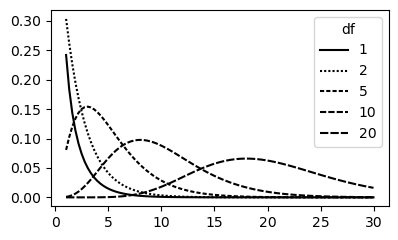

In [26]:
x = [1 + i * (30 - 1) / 99 for i in range(100)]

chi = pd.DataFrame({
    "x": x,
    "chi_1":  stats.chi2.pdf(x, df=1),
    "chi_2":  stats.chi2.pdf(x, df=2),
    "chi_5":  stats.chi2.pdf(x, df=5),
    "chi_10": stats.chi2.pdf(x, df=10),
    "chi_20": stats.chi2.pdf(x, df=20),
})

fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1,  color="black", linestyle="-",              label="1")
ax.plot(chi.x, chi.chi_2,  color="black", linestyle=(0, (1, 1)),      label="2")
ax.plot(chi.x, chi.chi_5,  color="black", linestyle=(0, (2, 1)),      label="5")
ax.plot(chi.x, chi.chi_10, color="black", linestyle=(0, (3, 1)),      label="10")
ax.plot(chi.x, chi.chi_20, color="black", linestyle=(0, (4, 1)),      label="20")
ax.legend(title="df")

plt.tight_layout()
plt.show()


In [27]:
# 2×2 교차표 생성
qsar["LogP_binary"] = (qsar["LogP"] > qsar["LogP"].median()).astype(int)
ct2 = pd.crosstab(qsar["LogP_binary"], qsar["MW_bin"])
print(ct2)

# SciPy Fisher's exact test
# 순서: [[a, b],
#       [c, d]]
table_2x2 = ct2.values  # shape (2,2)
oddsratio, pvalue_fisher = stats.fisher_exact(table_2x2)
print(f"Fisher exact odds ratio: {oddsratio:.4f}")
print(f"Fisher exact p-value: {pvalue_fisher:.4f}")


MW_bin        0   1
LogP_binary        
0            31  19
1            19  31
Fisher exact odds ratio: 2.6620
Fisher exact p-value: 0.0273


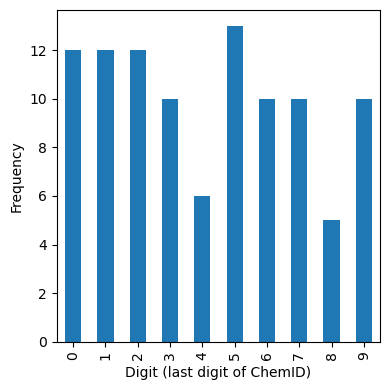

In [28]:
# ChemID의 마지막 자리수(0~9) 분포
digits = (qsar["ChemID"] % 10).astype(int)
imanishi = digits.value_counts().sort_index().reset_index()
imanishi.columns = ["Digit", "Frequency"]

ax = imanishi.plot.bar(x="Digit", y="Frequency", legend=False, figsize=(4, 4))
ax.set_xlabel("Digit (last digit of ChemID)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [29]:
from statsmodels.stats import power as smpower

# 예시 1: 클릭률 1.21% vs 1.10% 차이를 검출하기 위한 샘플 수
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = smpower.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05, power=0.8, alternative="larger")
print("Sample Size (example 1): %.3f" % result)

# 예시 2: 1.65% vs 1.10%
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = smpower.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05, power=0.8, alternative="larger")
print("Sample Size (example 2): %.3f" % result)


Sample Size (example 1): 116602.393
Sample Size (example 2): 5488.408
